**Header**

Predicting Museum Institution Affiliation\
Fall 2024 Data Science Project\
Joseph Vinik\
Contributions:\
Joseph Vinik - Selected the data set, cleaned data, performed exploratory analysis, selected and trained machine learning model, and performed analysis

Introduction:
The goal of this project is to see if it is possible to determine whether a musuem is affiliated with an institution. Hopefully throughout the course of this project I will be able to glean some insight into how being tied to an institution affects a museum. Museums are very important for educational outreach so it is important to understand them as best as possible.

**Data Curation**

My data came from a kaggle dataset that was compiled from the Institute of Museums and Libraries, IRS, and grant data.\
https://www.kaggle.com/datasets/imls/museum-directory

In [353]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import export_text

In [354]:
df = pd.read_csv('museums.csv')
display(df)

C:\Users\Josep\AppData\Local\Temp\ipykernel_24148\2873801153.py:1: DtypeWarning: Columns (0: Phone Number, 1: Employer ID Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('museums.csv')


,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,8405600184,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,PO BOX 73,SHERIDAN,WY,82801,...,44.82345,-106.87592,4.0,33.0,56.0,5,836007540.0,NaN,NaN,NaN
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,...,41.13941,-104.81813,1.0,21.0,56.0,5,237368629.0,201404.0,0.0,0.0
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,...,41.32276,-105.57686,3.0,1.0,56.0,5,830318392.0,201312.0,208508.0,83981.0
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,PO BOX 704,CHEYENNE,WY,82003,...,41.13010,-104.81916,1.0,21.0,56.0,5,830295570.0,201309.0,0.0,0.0


Upon loading in the data I got a warning that some columns had mixed data. A visual inspection of the data showed my that some values in the phone number and employer id number column had replacement characters. I noticed that removal of the replacement characters would fix the issues and would not cause the phone numbers or id numbers formats to become invalid. Additionally the number of affected values was 0.1% of the database so I decided the best course of action would be to remove the replacement characters.

In [355]:
def clean_int(x):
    x = str(x)
    ans = ''
    for i in x:
        if i.isdigit():
            ans += i
    if ans == '':
        return np.nan
    else:
        return int(ans)
    
df['Phone Number'] = df['Phone Number'].apply(clean_int)
df['Employer ID Number'] = df['Employer ID Number'].apply(clean_int)
display(df.dtypes)

Museum ID                                     int64
Museum Name                                     str
Legal Name                                      str
Alternate Name                                  str
Museum Type                                     str
Institution Name                                str
Street Address (Administrative Location)        str
City (Administrative Location)                  str
State (Administrative Location)                 str
Zip Code (Administrative Location)            int64
Street Address (Physical Location)              str
City (Physical Location)                        str
State (Physical Location)                       str
Zip Code (Physical Location)                float64
Phone Number                                float64
Latitude                                    float64
Longitude                                   float64
Locale Code (NCES)                          float64
County Code (FIPS)                          float64
State Code (

Here I changed some columns that were storing data as floats that could be ints

In [356]:
print('Before changes')
display(df.dtypes)
df = df.astype({
    'Zip Code (Physical Location)' : 'Int64',
    'Phone Number' : 'Int64',
    'Locale Code (NCES)' : 'Int64',
    'County Code (FIPS)' : 'Int64',
    'State Code (FIPS)' : 'Int64',
    'Region Code (AAM)' : 'Int64',
    'Employer ID Number' : 'Int64'})
print('\nAfter changes')
display(df.dtypes)

Before changes


Museum ID                                     int64
Museum Name                                     str
Legal Name                                      str
Alternate Name                                  str
Museum Type                                     str
Institution Name                                str
Street Address (Administrative Location)        str
City (Administrative Location)                  str
State (Administrative Location)                 str
Zip Code (Administrative Location)            int64
Street Address (Physical Location)              str
City (Physical Location)                        str
State (Physical Location)                       str
Zip Code (Physical Location)                float64
Phone Number                                float64
Latitude                                    float64
Longitude                                   float64
Locale Code (NCES)                          float64
County Code (FIPS)                          float64
State Code (


After changes


Museum ID                                     int64
Museum Name                                     str
Legal Name                                      str
Alternate Name                                  str
Museum Type                                     str
Institution Name                                str
Street Address (Administrative Location)        str
City (Administrative Location)                  str
State (Administrative Location)                 str
Zip Code (Administrative Location)            int64
Street Address (Physical Location)              str
City (Physical Location)                        str
State (Physical Location)                       str
Zip Code (Physical Location)                  Int64
Phone Number                                  Int64
Latitude                                    float64
Longitude                                   float64
Locale Code (NCES)                            Int64
County Code (FIPS)                            Int64
State Code (

By searching for several musuems on the internet I noticed that if the physical location and administrative locations were the same the physical location data would be omitted in the database so I copied the location from the administrative location columns to the physical location columns

In [357]:
def fill_address(row):
    if pd.isna(row['Street Address (Physical Location)']):
        return row['Street Address (Administrative Location)']
    else:
        return row['Street Address (Physical Location)']

def fill_city(row):
    if pd.isna(row['City (Physical Location)']):
        return row['City (Administrative Location)']
    else:
        return row['City (Physical Location)']

def fill_state(row):
    if pd.isna(row['State (Physical Location)']):
        return row['State (Administrative Location)']
    else:
        return row['State (Physical Location)']

def fill_zip(row):
    if pd.isna(row['Zip Code (Physical Location)']):
        return row['Zip Code (Administrative Location)']
    else:
        return row['Zip Code (Physical Location)']
        
df['Street Address (Physical Location)'] = df.apply(fill_address, axis=1)
df['City (Physical Location)'] = df.apply(fill_city, axis=1)
df['State (Physical Location)'] = df.apply(fill_state, axis=1)
df['Zip Code (Physical Location)'] = df.apply(fill_zip, axis=1)
display(df[['Museum Name', 
            'Street Address (Administrative Location)', 'Street Address (Physical Location)',
            'City (Administrative Location)', 'City (Physical Location)',
            'State (Administrative Location)', 'State (Physical Location)',
            'Zip Code (Administrative Location)', 'Zip Code (Physical Location)']])

,Museum Name,Street Address (Administrative Location),Street Address (Physical Location),City (Administrative Location),City (Physical Location),State (Administrative Location),State (Physical Location),Zip Code (Administrative Location),Zip Code (Physical Location)
0,ALASKA AVIATION HERITAGE MUSEUM,4721 AIRCRAFT DR,4721 AIRCRAFT DR,ANCHORAGE,ANCHORAGE,AK,AK,99502,99502
1,ALASKA BOTANICAL GARDEN,4601 CAMPBELL AIRSTRIP RD,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,ANCHORAGE,AK,AK,99507,99507
2,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,9711 KENAI SPUR HWY,9711 KENAI SPUR HWY,KENAI,KENAI,AK,AK,99611,99611
3,ALASKA EDUCATORS HISTORICAL SOCIETY,214 BIRCH STREET,214 BIRCH STREET,KENAI,KENAI,AK,AK,99611,99611
4,ALASKA HERITAGE MUSEUM,301 W NORTHERN LIGHTS BLVD,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,ANCHORAGE,AK,AK,99503,99503
...,...,...,...,...,...,...,...,...,...
33067,WYOMING STATE HISTORICAL SOCIETY,PO BOX 73,850 SIBLEY CIR,SHERIDAN,SHERIDAN,WY,WY,82801,82801
33068,WYOMING STATE MUSEUM,2301 CENTRAL AVENUE,2301 CENTRAL AVENUE,CHEYENNE,CHEYENNE,WY,WY,82001,82001
33069,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,1273 N 15TH ST STE 121,1273 N 15TH ST STE 121,LARAMIE,LARAMIE,WY,WY,82072,82072
33070,WYOMING TRANSPORTATION MUSEUM,PO BOX 704,121 W 15TH ST SUITE 300,CHEYENNE,CHEYENNE,WY,WY,82003,82003


Since I won't be needing the administrative locations or employer id numbers for my analysis I dropped these columns

In [358]:
df = df.drop(columns=['Museum ID', 
                        'Street Address (Administrative Location)',
                        'City (Administrative Location)', 
                        'State (Administrative Location)',
                        'Zip Code (Administrative Location)',
                        'Employer ID Number'])
display(df)

,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Physical Location),City (Physical Location),State (Physical Location),Zip Code (Physical Location),Phone Number,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Tax Period,Income,Revenue
0,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,9072485325,61.17925,-149.97254,1,20,2,6,201312.0,602912.0,550236.0
1,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,9077703692,61.16890,-149.76708,4,20,2,6,201312.0,1379576.0,1323742.0
2,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,9072832000,60.56149,-151.21598,3,122,2,6,201312.0,740030.0,729080.0
3,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,2142472478,60.56280,-151.26597,3,122,2,6,201412.0,0.0,0.0
4,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,9072652834,61.17925,-149.97254,1,20,2,6,201312.0,602912.0,550236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,850 SIBLEY CIR,SHERIDAN,WY,82801,30767511500,44.82345,-106.87592,4,33,56,5,NaN,NaN,NaN
33068,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,30777770220,41.13941,-104.81813,1,21,56,5,201404.0,0.0,0.0
33069,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,<NA>,41.32276,-105.57686,3,1,56,5,201312.0,208508.0,83981.0
33070,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,121 W 15TH ST SUITE 300,CHEYENNE,WY,82003,30763239050,41.13010,-104.81916,1,21,56,5,201309.0,0.0,0.0


Since the physical locations are now the only locations in the dataframe I decided to remove the specifier to make the column names cleaner

In [359]:
df.rename(columns={
    'Street Address (Physical Location)' : 'Street Address',
    'City (Physical Location)' : 'City',
    'State (Physical Location)' : 'State',
    'Zip Code (Physical Location)' : 'Zip Code'}, inplace=True)
display(df)

,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address,City,State,Zip Code,Phone Number,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Tax Period,Income,Revenue
0,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,9072485325,61.17925,-149.97254,1,20,2,6,201312.0,602912.0,550236.0
1,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,9077703692,61.16890,-149.76708,4,20,2,6,201312.0,1379576.0,1323742.0
2,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,9072832000,60.56149,-151.21598,3,122,2,6,201312.0,740030.0,729080.0
3,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,2142472478,60.56280,-151.26597,3,122,2,6,201412.0,0.0,0.0
4,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,9072652834,61.17925,-149.97254,1,20,2,6,201312.0,602912.0,550236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,850 SIBLEY CIR,SHERIDAN,WY,82801,30767511500,44.82345,-106.87592,4,33,56,5,NaN,NaN,NaN
33068,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,30777770220,41.13941,-104.81813,1,21,56,5,201404.0,0.0,0.0
33069,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,<NA>,41.32276,-105.57686,3,1,56,5,201312.0,208508.0,83981.0
33070,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,121 W 15TH ST SUITE 300,CHEYENNE,WY,82003,30763239050,41.13010,-104.81916,1,21,56,5,201309.0,0.0,0.0


Here I dropped any exact duplicate rows from the dataframe

In [360]:
display(df.duplicated().value_counts())
df.drop_duplicates(inplace=True)
display(df.duplicated().value_counts())

False    33067
True         5
Name: count, dtype: int64

False    33067
Name: count, dtype: int64

There are many museums with the exact same name so I decided to define duplicates as any row with the same name and street address.

In [361]:
print('Before dropping duplicates')
display(df[['Museum Name', 'Street Address']].value_counts())
df.drop_duplicates(subset=['Museum Name', 'Street Address'], inplace=True)
print('\nAfter dropping duplicates')
display(df[['Museum Name', 'Street Address']].value_counts())

Before dropping duplicates


Museum Name                                      Street Address         
ATCHISON COUNTY HISTORICAL SOCIETY               200 S 10TH ST              2
CLEVELAND COUNTY HISTORICAL SOCIETY              508 N PETERS AVE           2
ARMAND HAMMER MUSEUM OF ART AND CULTURAL CENTER  10899 WILSHIRE BLVD        2
HERITAGE SQUARE MUSEUM                           3800 HOMER STREET          2
LAKE ARROWHEAD CHILDREN'S MUSEUM                 28200 HIGHWAY 189          2
                                                                           ..
WYOMING STATE HISTORICAL SOCIETY                 850 SIBLEY CIR             1
WYOMING STATE MUSEUM                             2301 CENTRAL AVENUE        1
WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION    1273 N 15TH ST STE 121     1
WYOMING TRANSPORTATION MUSEUM                    121 W 15TH ST SUITE 300    1
YELLOWSTONE NATIONAL PARK                        NATIONAL PARK SERVICE      1
Name: count, Length: 33016, dtype: int64


After dropping duplicates


Museum Name                                            Street Address            
ALASKA AVIATION HERITAGE MUSEUM                        4721 AIRCRAFT DR              1
ALASKA BOTANICAL GARDEN                                4601 CAMPBELL AIRSTRIP RD     1
ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TECHNOLOGY  9711 KENAI SPUR HWY           1
ALASKA EDUCATORS HISTORICAL SOCIETY                    214 BIRCH STREET              1
ALASKA HERITAGE MUSEUM                                 301 W NORTHERN LIGHTS BLVD    1
                                                                                    ..
WYOMING STATE HISTORICAL SOCIETY                       850 SIBLEY CIR                1
WYOMING STATE MUSEUM                                   2301 CENTRAL AVENUE           1
WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION          1273 N 15TH ST STE 121        1
WYOMING TRANSPORTATION MUSEUM                          121 W 15TH ST SUITE 300       1
YELLOWSTONE NATIONAL PARK                       

**Exploratory Data Analysis**

The first thing I wanted to see about the database was the shape of the revenue data. To do this I created a symmetric boxplot of the revenue

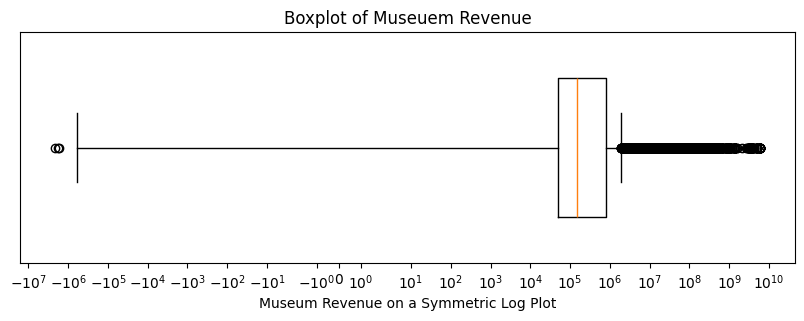

In [362]:
revenue = df[df['Income'] != 0]['Revenue'].dropna()
plt.figure(figsize=(10,3))
plt.boxplot(revenue, vert=False, widths=.6)
plt.xscale('symlog')
plt.title('Boxplot of Museuem Revenue')
plt.xlabel('Museum Revenue on a Symmetric Log Plot')
plt.yticks([])
plt.show()

Something I noticed on the boxplot was the number of high outliers so I decided to further investigate

In [363]:
q1 = revenue.quantile(.25)
q3 = revenue.quantile(.75)
iqr = q3 - q1

lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr

outliers = revenue[(revenue < lb) | (revenue > ub)]
print('Number of outliers: ' + str(outliers.count()))
print('Outliers as a percentage of revenue datapoints: ' + str(round(100 * outliers.count() / revenue.count(), 2)) + '%')
print('Percentage of outliers above the mean: ' + str(round(100 * revenue[revenue > ub].count() / outliers.count(), 2)) + '%')
print('Revenue median: ' + str(revenue.median()))
print('Revenue mean: ' + str(round(revenue.mean(), 2)))

Number of outliers: 2069
Outliers as a percentage of revenue datapoints: 17.93%
Percentage of outliers above the mean: 99.86%
Revenue median: 152558.0
Revenue mean: 40516496.57


Given the skew of the data and the substantial difference between the median and mean revenue it is best to use the median to describe the center of the data

The next point I want to know is the proportions of institution affiliated museums to non-affiliated museums. To start I created a column that says whether or not an institution is affiliated before creating a bar chart showing frequencies

In [364]:
def flip(x):
    if x:
        return 'Not Institution Affiliated'
    else:
        return 'Institution Affiliated'
df['Has Institution'] = df['Institution Name'].isna()
df['Has Institution'] = df['Has Institution'].apply(flip)

Has Institution
Not Institution Affiliated    30280
Institution Affiliated         2746
Name: count, dtype: int64

<BarContainer object of 2 artists>

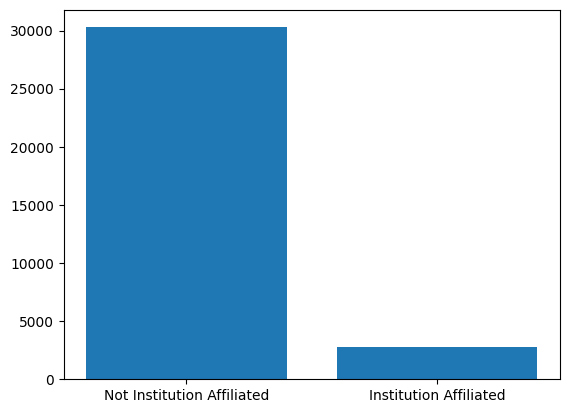

In [365]:
display(df['Has Institution'].value_counts())
plt.bar(['Not Institution Affiliated', 'Institution Affiliated'], df['Has Institution'].value_counts())

From the plot we can see that museums are much less likely to be affiliated than not. This imbalance will need to be accounted for in analysis. 

The next thing I want to know is whether institution affiliation affects revenue.

I used this new column to create a log bar chart comparing the median revenue from the two categories. I decided to use median revenue to compare the two because of my earlier result regarding the skew of revenue data.

Has Institution
Institution Affiliated        141683600.0
Not Institution Affiliated       151610.5
Name: Income, dtype: float64

<Axes: title={'center': 'Median Revenue Based on Institution Affiliation'}, ylabel='Median Revenue'>

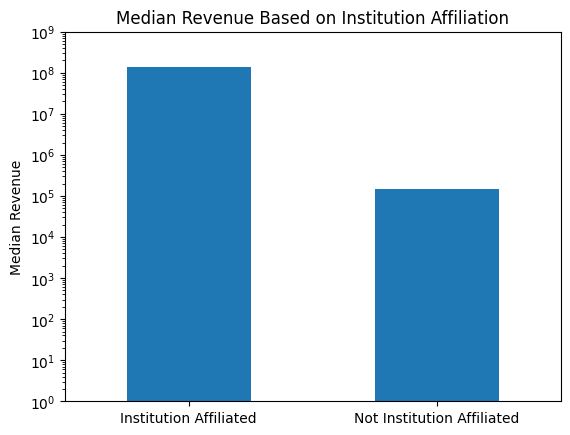

In [366]:
groups = df[df['Income'] != 0].dropna(subset='Income').groupby('Has Institution')['Income'].median()
display(groups)
groups.plot(kind='bar', logy=True, ylim=(1,1000000000), rot=0, ylabel='Median Revenue', xlabel='', title='Median Revenue Based on Institution Affiliation')

The bar chart demonstrates a substantial difference between the two groups

**Primary Analysis**

Here I am filling any nan values to get ready for machine learning and splitting the columns that I want into input and output variables.

In [367]:
df = df.fillna(0)
x = df[['Museum Type', 'City', 'State', 'Income', 'Revenue']]
y = df['Has Institution']
display(x)
display(y)

,Museum Type,City,State,Income,Revenue
0,HISTORY MUSEUM,ANCHORAGE,AK,602912.0,550236.0
1,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",ANCHORAGE,AK,1379576.0,1323742.0
2,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,KENAI,AK,740030.0,729080.0
3,HISTORIC PRESERVATION,KENAI,AK,0.0,0.0
4,HISTORY MUSEUM,ANCHORAGE,AK,602912.0,550236.0
...,...,...,...,...,...
33067,HISTORIC PRESERVATION,SHERIDAN,WY,0.0,0.0
33068,GENERAL MUSEUM,CHEYENNE,WY,0.0,0.0
33069,HISTORIC PRESERVATION,LARAMIE,WY,208508.0,83981.0
33070,HISTORY MUSEUM,CHEYENNE,WY,0.0,0.0


0        Not Institution Affiliated
1        Not Institution Affiliated
2        Not Institution Affiliated
3        Not Institution Affiliated
4        Not Institution Affiliated
                    ...            
33067    Not Institution Affiliated
33068    Not Institution Affiliated
33069    Not Institution Affiliated
33070    Not Institution Affiliated
33071    Not Institution Affiliated
Name: Has Institution, Length: 33026, dtype: str

Here I am making sure all of the categorical data is converted to ints with each value matching a different category and changing institutions from a string format to a true or false format. 

In [368]:
x['Museum Type'] = x['Museum Type'].astype('category').cat.codes.astype(int)
x['City'] = x['City'].astype('category').cat.codes.astype(int)
x['State'] = x['State'].astype('category').cat.codes.astype(int)

In [369]:
def institution(x):
    return x == 'Institution Affiliated'
y = y.apply(institution)

Here I am splitting x and y into testing and validation sets for the machine learning model

In [370]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
display(x_train.shape)
display(y_train.shape)
display(x_test.shape)
display(y_test.shape)

(26420, 5)

(26420,)

(6606, 5)

(6606,)

The machine learning model I decided to use was a random forest classifier. I chose this model for several reasons. The first is that the prediction I want to perform is a classification and although a regression model could perform the task a classifier should be cleaner and easier. The second is that I have a lot of categorical data as inputs which makes a random forest or decision tree better than a KNN model. Finally I chose a random forest over a simpler decision tree because does better at handling noisy datasets.

There are several hyperparemeter and models I want to tweak to determine the best model for classification. For models I will be trying both the random forest classifier from scikitlearn and the balanced random forest classifer from imbalanced learn since institution affiliation is imbalanced. I will also test the random forest classifier with the class weights parameter set to balanced and balanced subset to see if either improves the performance. Finally I will also be testing a number of max depths for each model.

In [371]:
model_accuracy = {
    'random forest': [],
    'random forest balanced': [],
    'random forest balanced subset': [],
    'balanced random forest': []
}
depth_range_min = 1
depth_range_max = 30
for i in range(depth_range_min,depth_range_max):
    models = {
        'random forest': RandomForestClassifier(max_depth=i),
        'random forest balanced': RandomForestClassifier(max_depth=i,class_weight='balanced'),
        'random forest balanced subset': RandomForestClassifier(max_depth=i, class_weight='balanced_subsample'),
        'balanced random forest': BalancedRandomForestClassifier(max_depth=i)
    }
    for name, model in models.items():
        print(i)
        print(name)
        model.fit(x_train,y_train)

        preds = model.predict(x_test)
        model_accuracy[name].append(accuracy_score(y_test,preds))

print(model_accuracy)

1
random forest
1
random forest balanced
1
random forest balanced subset
1
balanced random forest
2
random forest
2
random forest balanced
2
random forest balanced subset
2
balanced random forest
3
random forest
3
random forest balanced
3
random forest balanced subset
3
balanced random forest
4
random forest
4
random forest balanced
4
random forest balanced subset
4
balanced random forest
5
random forest
5
random forest balanced
5
random forest balanced subset
5
balanced random forest
6
random forest
6
random forest balanced
6
random forest balanced subset
6
balanced random forest
7
random forest
7
random forest balanced
7
random forest balanced subset
7
balanced random forest
8
random forest
8
random forest balanced
8
random forest balanced subset
8
balanced random forest
9
random forest
9
random forest balanced
9
random forest balanced subset
9
balanced random forest
10
random forest
10
random forest balanced
10
random forest balanced subset
10
balanced random forest
11
random forest

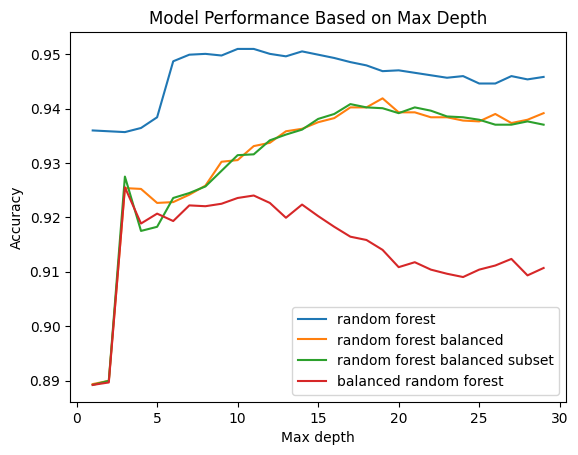

In [372]:
for name, data in model_accuracy.items():
    plt.plot(range(depth_range_min,depth_range_max), data, label=name)
plt.title('Model Performance Based on Max Depth')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

We can clearly see that despite the imbalance in institution affiliation the standard random forest model performs the best of all the models. We can now also determine which max depth performed the best.

In [373]:
best_depth = 0
best_accuracy = 0
for i in range(len(model_accuracy['random forest'])):
    accuracy = model_accuracy['random forest'][i]
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_depth = i + 1
print('best depth: ' + str(best_depth))
print('best accuracy: ' + str(best_accuracy))

best depth: 10
best accuracy: 0.9509536784741145


We now have the best combination of model configurations which is a random forest model with a maximum depth of 9 and no class weightings

**Conclusion**

We can now run the model with some additional tools to get a more detailed report on the performance of the model.

In [375]:
model = RandomForestClassifier(max_depth=best_depth, random_state=42)
model.fit(x_train,y_train)

preds = model.predict(x_test)
accuracy = accuracy_score(y_test, preds)
report = classification_report(y_test, preds)
print('accuracy: ' + str(accuracy))
print(str(report))

accuracy: 0.9500454132606722
              precision    recall  f1-score   support

       False       0.97      0.98      0.97      6020
        True       0.74      0.68      0.71       586

    accuracy                           0.95      6606
   macro avg       0.85      0.83      0.84      6606
weighted avg       0.95      0.95      0.95      6606



We can see that precision and recall are much better false predictions than true predictions. This is not surprising given the imbalance in affiliation. The relatively low number of true values is going to bias the model towards false predictions.

Next I want to look at which feature was the most important for the models predictions. For this I will be averaging the entropy reduction for each model that makes up the random forest.

Museum Type    0.386197
Revenue        0.284166
Income         0.226886
City           0.063512
State          0.039239
dtype: float64

<BarContainer object of 5 artists>

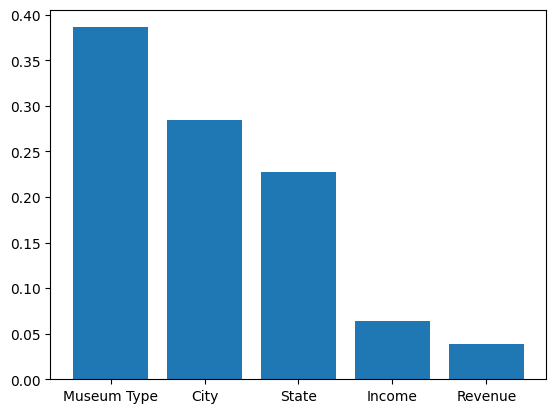

In [376]:
trees = model.estimators_
importances = [i.feature_importances_ for i in trees]
importances = pd.DataFrame(importances)
importances.rename(columns={0:'Museum Type', 1:'City', 2:'State', 3:'Income', 4:'Revenue'},inplace=True)
importances = importances.mean()
importances = importances.sort_values(ascending=False)
display(importances)
plt.bar(x_train.columns, importances)

We can see from the plot that museum type was the best predictor of whether or not a museum was institution affiliated. A surprising result was that despite seeing a large gap between the revenue of affilated and non-affilated museums in exploratory analysis income and revenue were the least predictive features by a large margin.